# RoBERTa Multi-Class Diagnosis Models

Trains **two** RoBERTa classifiers on `multiclass_df`:

1. **3-class severity model** — predicts `threeclass_label`.
2. **Subreddit model** — predicts `multiclass_label` (after dropping ultra-rare classes).

Each model gets its own 80/10/10 stratified split, class-weighted loss, and checkpoint.

## Section 1: Imports

In [4]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


## Section 2: Load `multiclass_df` and minimal preprocessing

In [5]:
multiclass_df=pd.read_csv("multiclass_df.csv")

In [6]:
# multiclass_df is expected to already exist in the kernel with columns:
#   other_posts, multiclass_label, threeclass_label
# If you need to load it from disk, uncomment the line below:
# multiclass_df = pd.read_csv('multiclass_df.csv')

data = multiclass_df.sample(frac=1, random_state=42).reset_index(drop=True)

print('Dataset shape:', data.shape)
print('\nColumns:', data.columns.tolist())
print('\nthreeclass_label distribution:')
print(data['threeclass_label'].value_counts(dropna=False))
print('\nmulticlass_label distribution:')
print(data['multiclass_label'].value_counts(dropna=False))

Dataset shape: (81544, 13)

Columns: ['author', 'subreddit', 'report_post', 'other_posts', 'is_self_report', 'is_control', 'self_report_sentence', 'selfdiag_score', 'selfdiag_matches', 'severe_flag', 'label', 'multiclass_label', 'threeclass_label']

threeclass_label distribution:
threeclass_label
normal      48055
at_risk     19120
suicidal    14369
Name: count, dtype: int64

multiclass_label distribution:
multiclass_label
control          48055
suicidewatch     14369
adhd              4164
anxiety           3457
depression        3244
mentalhealth      2663
socialanxiety     1010
bpd                984
ptsd               884
autism             572
schizophrenia      460
healthanxiety      418
bipolarreddit      350
edanonymous        318
lonely             295
addiction          173
alcoholism         128
Name: count, dtype: int64


In [7]:
def minimal_preprocess(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['other_posts'] = data['other_posts'].apply(minimal_preprocess)
data = data[data['other_posts'].str.len() > 0].reset_index(drop=True)
print(f'After cleaning empty text: {len(data)} rows')

After cleaning empty text: 81146 rows


## Section 3: Shared building blocks (Dataset, train, eval)

In [8]:
class TextClassificationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


def train_epoch(model, train_loader, optimizer, scheduler, device, loss_fn):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc='Training'):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop('labels')
        outputs = model(**batch)
        loss = loss_fn(outputs.logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


def evaluate(model, eval_loader, device, loss_fn):
    model.eval()
    total_loss = 0
    predictions, true_labels = [], []
    with torch.no_grad():
        for batch in tqdm(eval_loader, desc='Evaluating'):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('labels')
            outputs = model(**batch)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())
    return total_loss / len(eval_loader), accuracy_score(true_labels, predictions), predictions, true_labels


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

MODEL_NAME = 'roberta-base'
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)
MAX_LENGTH = 256
BATCH_SIZE = 16
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5

Using device: cuda


## Section 4: End-to-end training function

Given a dataframe + label column, this prepares splits, encodes labels, computes class weights, trains a RoBERTa model, and reports macro / weighted P/R/F1 plus a confusion matrix. We call it twice — once per label column.

In [10]:
def run_experiment(df, label_col, model_save_path, min_samples_per_class=50):
    print('=' * 70)
    print(f'EXPERIMENT: {label_col}  ->  {model_save_path}')
    print('=' * 70)

    # 1. Drop NaN labels / empty text
    work = df.dropna(subset=[label_col, 'other_posts']).copy()

    # 2. Drop ultra-rare classes
    counts = work[label_col].value_counts()
    keep_classes = counts[counts >= min_samples_per_class].index.tolist()
    dropped = counts[counts < min_samples_per_class]
    if len(dropped) > 0:
        print(f'Dropping {len(dropped)} classes with < {min_samples_per_class} samples:')
        for cls, n in dropped.items():
            print(f'  - {cls}: {n}')
    work = work[work[label_col].isin(keep_classes)].reset_index(drop=True)

    # 3. Encode string labels -> integers
    le = LabelEncoder()
    work['_y'] = le.fit_transform(work[label_col].astype(str))
    class_names = list(le.classes_)
    num_labels = len(class_names)
    print(f'\nFinal: {len(work)} rows, {num_labels} classes')
    print('Class distribution:')
    for i, name in enumerate(class_names):
        print(f'  {i:2d} {name:<25} {(work["_y"] == i).sum()}')

    # 4. 80/10/10 stratified split
    train_df, temp_df = train_test_split(work, test_size=0.2, random_state=42, stratify=work['_y'])
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['_y'])
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    print(f'\nSplit sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}')

    # 5. Tokenize
    def tok(texts):
        return tokenizer(texts.tolist(), max_length=MAX_LENGTH, padding='max_length',
                         truncation=True, return_tensors='pt')

    print('\nTokenizing...')
    train_enc = tok(train_df['other_posts'])
    val_enc = tok(val_df['other_posts'])
    test_enc = tok(test_df['other_posts'])

    train_ds = TextClassificationDataset(train_enc, train_df['_y'].values)
    val_ds = TextClassificationDataset(val_enc, val_df['_y'].values)
    test_ds = TextClassificationDataset(test_enc, test_df['_y'].values)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # 6. Model + class-weighted loss
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)

    cw = compute_class_weight('balanced', classes=np.arange(num_labels), y=train_df['_y'].values)
    class_weights = torch.tensor(cw, dtype=torch.float).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    print(f'\nClass weights computed (min={cw.min():.3f}, max={cw.max():.3f})')

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_loader) * NUM_EPOCHS
    scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, total_iters=total_steps)

    # 7. Training loop — select on macro-F1
    best_val_f1 = 0.0
    for epoch in range(NUM_EPOCHS):
        print(f'\n--- Epoch {epoch + 1}/{NUM_EPOCHS} ---')
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, device, loss_fn)
        print(f'Train loss: {train_loss:.4f}')
        val_loss, val_acc, val_preds, val_true = evaluate(model, val_loader, device, loss_fn)
        val_macro_f1 = f1_score(val_true, val_preds, average='macro', zero_division=0)
        print(f'Val loss: {val_loss:.4f}  acc: {val_acc:.4f}  macro-F1: {val_macro_f1:.4f}')
        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            torch.save(model.state_dict(), model_save_path)
            print(f'  -> saved best model to {model_save_path}')

    # 8. Final test eval with best checkpoint
    model.load_state_dict(torch.load(model_save_path))
    test_loss, test_acc, test_preds, test_true = evaluate(model, test_loader, device, loss_fn)
    print('\n' + '=' * 70)
    print(f'TEST RESULTS — {label_col}')
    print('=' * 70)
    print(f'Loss:        {test_loss:.4f}')
    print(f'Accuracy:    {test_acc:.4f}')
    print(f'Macro    P/R/F1: '
          f'{precision_score(test_true, test_preds, average="macro", zero_division=0):.4f} / '
          f'{recall_score(test_true, test_preds, average="macro", zero_division=0):.4f} / '
          f'{f1_score(test_true, test_preds, average="macro", zero_division=0):.4f}')
    print(f'Weighted P/R/F1: '
          f'{precision_score(test_true, test_preds, average="weighted", zero_division=0):.4f} / '
          f'{recall_score(test_true, test_preds, average="weighted", zero_division=0):.4f} / '
          f'{f1_score(test_true, test_preds, average="weighted", zero_division=0):.4f}')
    print('\nClassification report:')
    print(classification_report(test_true, test_preds, target_names=class_names, zero_division=0))
    print('Confusion matrix (rows=true, cols=pred):')
    cm = confusion_matrix(test_true, test_preds, labels=list(range(num_labels)))
    print(cm)

    return {
        'model': model,
        'label_encoder': le,
        'class_names': class_names,
        'test_acc': test_acc,
        'test_macro_f1': f1_score(test_true, test_preds, average='macro', zero_division=0),
    }


## Section 5: Train Model 1 — 3-class severity (`threeclass_label`)

In [11]:
result_3class = run_experiment(
    df=data,
    label_col='threeclass_label',
    model_save_path='best_roberta_threeclass.pt',
    min_samples_per_class=50,
)

EXPERIMENT: threeclass_label  ->  best_roberta_threeclass.pt

Final: 81146 rows, 3 classes
Class distribution:
   0 at_risk                   18930
   1 normal                    47847
   2 suicidal                  14369

Split sizes: train=64916, val=8115, test=8115

Tokenizing...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Class weights computed (min=0.565, max=1.882)

--- Epoch 1/3 ---


Training: 100%|██████████| 4058/4058 [38:20<00:00,  1.76it/s]


Train loss: 0.3726


...

Train loss: 0.2359


Evaluating: 100%|██████████| 508/508 [01:35<00:00,  5.35it/s]


Val loss: 0.3108  acc: 0.8753  macro-F1: 0.8646


Evaluating: 100%|██████████| 508/508 [01:30<00:00,  5.61it/s]



TEST RESULTS — threeclass_label
Loss:        0.3378
Accuracy:    0.8819
Macro    P/R/F1: 0.8598 / 0.8714 / 0.8652
Weighted P/R/F1: 0.8829 / 0.8819 / 0.8822

Classification report:
              precision    recall  f1-score   support

     at_risk       0.83      0.82      0.82      1893
      normal       0.92      0.90      0.91      4785
    suicidal       0.83      0.89      0.86      1437

    accuracy                           0.88      8115
   macro avg       0.86      0.87      0.87      8115
weighted avg       0.88      0.88      0.88      8115

Confusion matrix (rows=true, cols=pred):
[[1553  263   77]
 [ 275 4325  185]
 [  44  114 1279]]


## Section 6: Train Model 2 — Subreddit model (`multiclass_label`)

In [12]:
result_multiclass = run_experiment(
    df=data,
    label_col='multiclass_label',
    model_save_path='best_roberta_multiclass.pt',
    min_samples_per_class=50,  # drops jokes (6), covid19_support (37)
)

EXPERIMENT: multiclass_label  ->  best_roberta_multiclass.pt

Final: 81146 rows, 17 classes
Class distribution:
   0 addiction                 168
   1 adhd                      4144
   2 alcoholism                128
   3 anxiety                   3439
   4 autism                    562
   5 bipolarreddit             349
   6 bpd                       982
   7 control                   47847
   8 depression                3182
   9 edanonymous               316
  10 healthanxiety             414
  11 lonely                    288
  12 mentalhealth              2636
  13 ptsd                      879
  14 schizophrenia             454
  15 socialanxiety             989
  16 suicidewatch              14369

Split sizes: train=64916, val=8115, test=8115

Tokenizing...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Class weights computed (min=0.100, max=37.074)

--- Epoch 1/3 ---


Training: 100%|██████████| 4058/4058 [37:58<00:00,  1.78it/s]


Train loss: 1.9381


...

Train loss: 1.3245


Evaluating: 100%|██████████| 508/508 [01:26<00:00,  5.86it/s]


Val loss: 1.5002  acc: 0.7193  macro-F1: 0.4159
  -> saved best model to best_roberta_multiclass.pt


Evaluating: 100%|██████████| 508/508 [01:26<00:00,  5.84it/s]



TEST RESULTS — multiclass_label
Loss:        1.5797
Accuracy:    0.7139
Macro    P/R/F1: 0.3598 / 0.5325 / 0.4020
Weighted P/R/F1: 0.7956 / 0.7139 / 0.7382

Classification report:
               precision    recall  f1-score   support

    addiction       0.18      0.59      0.27        17
         adhd       0.66      0.64      0.65       414
   alcoholism       0.35      0.58      0.44        12
      anxiety       0.36      0.55      0.43       344
       autism       0.23      0.48      0.31        56
bipolarreddit       0.21      0.29      0.24        35
          bpd       0.33      0.45      0.38        98
      control       0.98      0.75      0.85      4785
   depression       0.34      0.34      0.34       318
  edanonymous       0.33      0.66      0.44        32
healthanxiety       0.30      0.48      0.37        42
       lonely       0.07      0.59      0.13        29
 mentalhealth       0.30      0.11      0.16       264
         ptsd       0.35      0.53      0.42    

## Section 7: Summary

In [13]:
print('=' * 60)
print('FINAL SUMMARY — RoBERTa')
print('=' * 60)
print(f"3-class model    | classes={len(result_3class['class_names'])}    | "
      f"test acc={result_3class['test_acc']:.4f} | macro-F1={result_3class['test_macro_f1']:.4f}")
print(f"Subreddit model  | classes={len(result_multiclass['class_names'])}   | "
      f"test acc={result_multiclass['test_acc']:.4f} | macro-F1={result_multiclass['test_macro_f1']:.4f}")

FINAL SUMMARY — RoBERTa
3-class model    | classes=3    | test acc=0.8819 | macro-F1=0.8652
Subreddit model  | classes=17   | test acc=0.7139 | macro-F1=0.4020


In [ ]:
model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)

# Load best model for final evaluation
model.load_state_dict(torch.load('best_roberta_threeclass.pt'))

input_text= "I feel so empty inside. I don't know what to do anymore."
 
input_text=minimal_preprocess(input_text)
inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=512)

# Move inputs to the same device as the model
inputs = {key: val.to(device) for key, val in inputs.items()}

# Perform inference
model.eval()
with torch.no_grad():
	outputs = model(**inputs)
	logits = outputs.logits
	probs = torch.softmax(logits, dim=1)
	p1 = probs[:, 1]
	predicted_class = int(p1.item()>=0.1)
print(logits)
print(probs)
print(f"Predicted class: {predicted_class}")


In [3]:
def predict_single(text, model_path, num_labels, class_names):
    """Predict the class of a single text input using a trained RoBERTa checkpoint."""
    # Rebuild model architecture and load weights
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Preprocess + tokenize
    clean = minimal_preprocess(text)
    enc = tokenizer(
        clean,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    ).to(device)

    # Forward pass
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(probs.argmax())
    pred_label = class_names[pred_idx]

    print(f'Input: {text[:120]}{"..." if len(text) > 120 else ""}')
    print(f'\nPredicted class: {pred_label}  (confidence: {probs[pred_idx]:.4f})')
    print('\nTop 5 probabilities:')
    top5 = np.argsort(probs)[::-1][:5]
    for i in top5:
        print(f'  {class_names[i]:<25} {probs[i]:.4f}')

    return pred_label, probs

In [15]:
# Example text
sample_text = "I've been feeling really overwhelmed lately, can't sleep, and everything feels pointless. I don't know what to do anymore."

# Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass.pt',
    num_labels=len(result_3class['class_names']),
    class_names=result_3class['class_names'],
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)

=== 3-class severity model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I've been feeling really overwhelmed lately, can't sleep, and everything feels pointless. I don't know what to do anymor...

Predicted class: suicidal  (confidence: 0.7081)

Top 5 probabilities:
  suicidal                  0.7081
  normal                    0.1780
  at_risk                   0.1140

=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I've been feeling really overwhelmed lately, can't sleep, and everything feels pointless. I don't know what to do anymor...

Predicted class: suicidewatch  (confidence: 0.8085)

Top 5 probabilities:
  suicidewatch              0.8085
  depression                0.0946
  control                   0.0434
  lonely                    0.0154
  mentalhealth              0.0110


('suicidewatch',
 array([4.2935822e-04, 1.2033596e-03, 8.9871819e-04, 5.4424023e-03,
        1.6243063e-03, 1.0775443e-03, 4.9858773e-03, 4.3417566e-02,
        9.4592459e-02, 4.1195028e-03, 1.1555371e-03, 1.5392760e-02,
        1.0989857e-02, 3.3146481e-03, 1.0139506e-03, 1.8516454e-03,
        8.0849057e-01], dtype=float32))

In [16]:
# Example text
sample_text = "I've been feeling really overwhelmed lately."

# Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass.pt',
    num_labels=len(result_3class['class_names']),
    class_names=result_3class['class_names'],
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)

=== 3-class severity model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I've been feeling really overwhelmed lately.

Predicted class: normal  (confidence: 0.4841)

Top 5 probabilities:
  normal                    0.4841
  suicidal                  0.2966
  at_risk                   0.2193

=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I've been feeling really overwhelmed lately.

Predicted class: control  (confidence: 0.2638)

Top 5 probabilities:
  control                   0.2638
  depression                0.1824
  suicidewatch              0.1260
  anxiety                   0.1245
  mentalhealth              0.1069


('control',
 array([0.00162971, 0.01472993, 0.00256745, 0.12452365, 0.01897616,
        0.00771739, 0.03036887, 0.26381397, 0.18239333, 0.02102452,
        0.00901585, 0.01604464, 0.10686456, 0.04455336, 0.0070738 ,
        0.02265409, 0.12604874], dtype=float32))

In [17]:
# Example text
sample_text = "I feel so empty inside. I don't know what to do anymore."

# Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass.pt',
    num_labels=len(result_3class['class_names']),
    class_names=result_3class['class_names'],
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)

=== 3-class severity model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I feel so empty inside. I don't know what to do anymore.

Predicted class: suicidal  (confidence: 0.9586)

Top 5 probabilities:
  suicidal                  0.9586
  normal                    0.0313
  at_risk                   0.0101

=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I feel so empty inside. I don't know what to do anymore.

Predicted class: suicidewatch  (confidence: 0.9378)

Top 5 probabilities:
  suicidewatch              0.9378
  lonely                    0.0182
  depression                0.0165
  control                   0.0165
  edanonymous               0.0019


('suicidewatch',
 array([4.6106731e-04, 3.6287273e-04, 7.0734584e-04, 7.8582962e-04,
        7.6333340e-04, 4.2882751e-04, 1.7118603e-03, 1.6529260e-02,
        1.6538514e-02, 1.8596187e-03, 5.0789793e-04, 1.8227099e-02,
        1.4997171e-03, 7.2399684e-04, 4.8194840e-04, 6.2178617e-04,
        9.3778908e-01], dtype=float32))

In [18]:
# Example text
sample_text = "I don't know what to live anymore."

# Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass.pt',
    num_labels=len(result_3class['class_names']),
    class_names=result_3class['class_names'],
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)

=== 3-class severity model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I don't know what to live anymore.

Predicted class: suicidal  (confidence: 0.9902)

Top 5 probabilities:
  suicidal                  0.9902
  normal                    0.0059
  at_risk                   0.0039

=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I don't know what to live anymore.

Predicted class: suicidewatch  (confidence: 0.9690)

Top 5 probabilities:
  suicidewatch              0.9690
  depression                0.0101
  control                   0.0059
  lonely                    0.0034
  edanonymous               0.0025


('suicidewatch',
 array([3.3151309e-04, 3.8004699e-04, 5.4265960e-04, 8.3931815e-04,
        7.6294196e-04, 2.7394429e-04, 1.8032081e-03, 5.9165307e-03,
        1.0124655e-02, 2.4741325e-03, 3.4143319e-04, 3.4261234e-03,
        1.5960729e-03, 9.9523133e-04, 5.3913717e-04, 6.5140304e-04,
        9.6900159e-01], dtype=float32))

In [4]:
# Example text
sample_text = "I'm fine."

# Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass.pt',
    num_labels=len(result_3class['class_names']),
    class_names=result_3class['class_names'],
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)

=== 3-class severity model ===


NameError: name 'result_3class' is not defined

In [ ]:
# Example text
sample_text = "I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that."

# Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass.pt',
    num_labels=len(result_3class['class_names']),
    class_names=result_3class['class_names'],
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)

In [ ]:
# Example text
sample_text = "I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that."

# Predict with the 3-class severity model
print('=== 3-class severity model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_threeclass.pt',
    num_labels=len(result_3class['class_names']),
    class_names=result_3class['class_names'],
)

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)

=== 3-class severity model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that.

Predicted class: suicidal  (confidence: 0.6288)

Top 5 probabilities:
  suicidal                  0.6288
  normal                    0.1905
  at_risk                   0.1806

=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that.

Predicted class: suicidewatch  (confidence: 0.5102)

Top 5 probabilities:
  suicidewatch              0.5102
  depression                0.1697
  anxiety                   0.1412
  mentalhealth              0.0449
  control                   0.0395


('suicidewatch',
 array([0.00089753, 0.00456414, 0.00160993, 0.14123027, 0.00697922,
        0.00205354, 0.00625815, 0.03946045, 0.16971743, 0.0133154 ,
        0.00599362, 0.01860049, 0.04492855, 0.00486298, 0.00385055,
        0.02543879, 0.51023895], dtype=float32))

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Scoring: 100%|██████████| 508/508 [01:25<00:00,  5.92it/s]


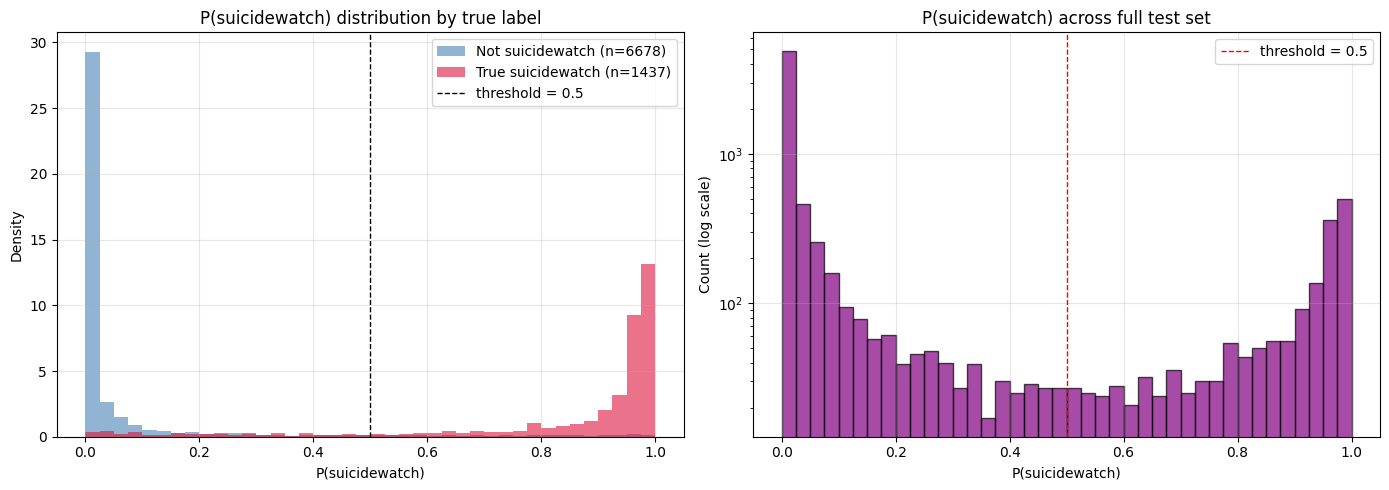


=== Stats for P(suicidewatch) ===
True suicidewatch samples (n=1437):
  mean=0.8433  median=0.9600  std=0.2437
  % above 0.5: 89.1%

Other samples (n=6678):
  mean=0.0738  median=0.0054  std=0.1869
  % above 0.5: 5.5%


In [25]:
import matplotlib.pyplot as plt

def plot_suicidal_probability_distribution(model_path, result_dict, label_col='multiclass_label',
                                            suicidal_class='suicidewatch'):
    """
    Plot the distribution of P(suicidal) across the test set,
    split by true label (suicidal vs not).
    """
    class_names = result_dict['class_names']
    num_labels = len(class_names)

    if suicidal_class not in class_names:
        raise ValueError(f"'{suicidal_class}' not in class names: {class_names}")
    suicidal_idx = class_names.index(suicidal_class)

    # Rebuild model and load weights
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Recreate the same test split used in run_experiment
    work = data.dropna(subset=[label_col, 'other_posts']).copy()
    counts = work[label_col].value_counts()
    keep = counts[counts >= 50].index.tolist()
    work = work[work[label_col].isin(keep)].reset_index(drop=True)
    le = result_dict['label_encoder']
    work['_y'] = le.transform(work[label_col].astype(str))

    _, temp_df = train_test_split(work, test_size=0.2, random_state=42, stratify=work['_y'])
    _, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['_y'])
    test_df = test_df.reset_index(drop=True)

    # Tokenize and run inference, collecting P(suicidal)
    enc = tokenizer(test_df['other_posts'].tolist(), max_length=MAX_LENGTH,
                    padding='max_length', truncation=True, return_tensors='pt')
    ds = TextClassificationDataset(enc, test_df['_y'].values)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)

    all_probs, all_true = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Scoring'):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('labels')
            logits = model(**batch).logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_true.extend(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_true = np.array(all_true)
    suicidal_probs = all_probs[:, suicidal_idx]

    is_suicidal = (all_true == suicidal_idx)
    probs_pos = suicidal_probs[is_suicidal]
    probs_neg = suicidal_probs[~is_suicidal]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: overlaid histograms
    bins = np.linspace(0, 1, 41)
    axes[0].hist(probs_neg, bins=bins, alpha=0.6, label=f'Not {suicidal_class} (n={len(probs_neg)})',
                 color='steelblue', density=True)
    axes[0].hist(probs_pos, bins=bins, alpha=0.6, label=f'True {suicidal_class} (n={len(probs_pos)})',
                 color='crimson', density=True)
    axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1, label='threshold = 0.5')
    axes[0].set_xlabel(f'P({suicidal_class})')
    axes[0].set_ylabel('Density')
    axes[0].set_title(f'P({suicidal_class}) distribution by true label')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Right: log-scale full test set
    axes[1].hist(suicidal_probs, bins=bins, color='purple', alpha=0.7, edgecolor='black')
    axes[1].set_yscale('log')
    axes[1].set_xlabel(f'P({suicidal_class})')
    axes[1].set_ylabel('Count (log scale)')
    axes[1].set_title(f'P({suicidal_class}) across full test set')
    axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1, label='threshold = 0.5')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('suicidal_probability_distribution.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Stats
    print(f'\n=== Stats for P({suicidal_class}) ===')
    print(f'True {suicidal_class} samples (n={len(probs_pos)}):')
    print(f'  mean={probs_pos.mean():.4f}  median={np.median(probs_pos):.4f}  '
          f'std={probs_pos.std():.4f}')
    print(f'  % above 0.5: {(probs_pos >= 0.5).mean() * 100:.1f}%')
    print(f'\nOther samples (n={len(probs_neg)}):')
    print(f'  mean={probs_neg.mean():.4f}  median={np.median(probs_neg):.4f}  '
          f'std={probs_neg.std():.4f}')
    print(f'  % above 0.5: {(probs_neg >= 0.5).mean() * 100:.1f}%')

    return suicidal_probs, all_true


probs, true = plot_suicidal_probability_distribution(
    model_path='best_roberta_multiclass.pt',
    result_dict=result_multiclass,
    label_col='multiclass_label',
    suicidal_class='suicidewatch',
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Scoring: 100%|██████████| 508/508 [01:27<00:00,  5.83it/s]


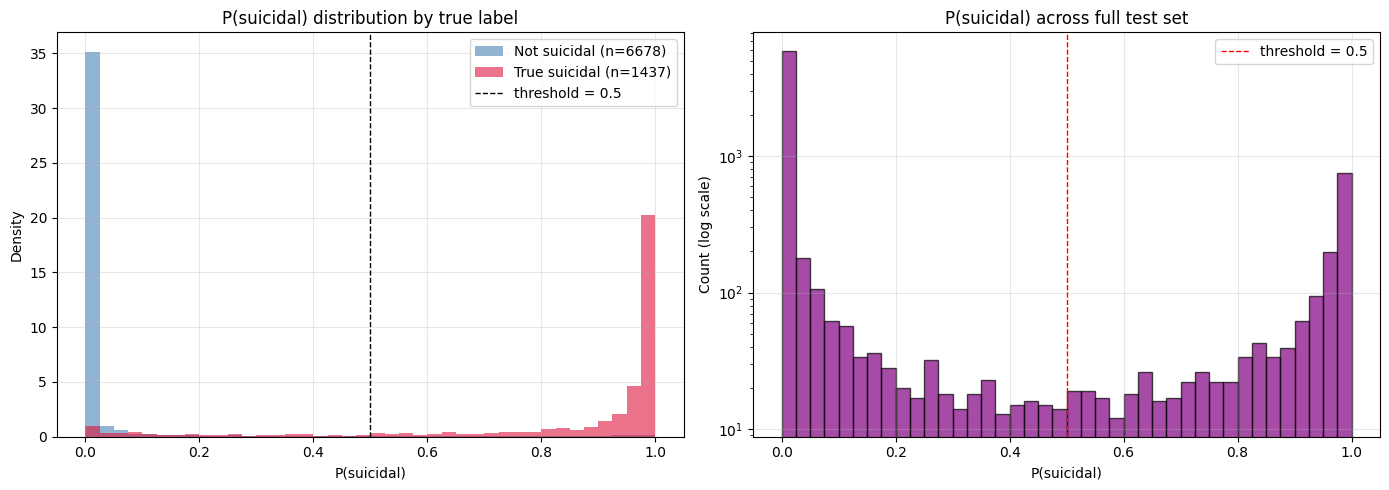


=== Stats for P(suicidal) ===
True suicidal samples (n=1437):
  mean=0.8418  median=0.9759  std=0.2684
  % above 0.5: 88.0%

Other samples (n=6678):
  mean=0.0420  median=0.0011  std=0.1562
  % above 0.5: 3.4%


In [28]:
import matplotlib.pyplot as plt

def plot_suicidal_probability_distribution(model_path, result_dict, label_col='threeclass_label',
                                            suicidal_class='suicidewatch'):
    """
    Plot the distribution of P(suicidal) across the test set,
    split by true label (suicidal vs not).
    """
    class_names = result_dict['class_names']
    num_labels = len(class_names)

    if suicidal_class not in class_names:
        raise ValueError(f"'{suicidal_class}' not in class names: {class_names}")
    suicidal_idx = class_names.index(suicidal_class)

    # Rebuild model and load weights
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Recreate the same test split used in run_experiment
    work = data.dropna(subset=[label_col, 'other_posts']).copy()
    counts = work[label_col].value_counts()
    keep = counts[counts >= 50].index.tolist()
    work = work[work[label_col].isin(keep)].reset_index(drop=True)
    le = result_dict['label_encoder']
    work['_y'] = le.transform(work[label_col].astype(str))

    _, temp_df = train_test_split(work, test_size=0.2, random_state=42, stratify=work['_y'])
    _, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['_y'])
    test_df = test_df.reset_index(drop=True)

    # Tokenize and run inference, collecting P(suicidal)
    enc = tokenizer(test_df['other_posts'].tolist(), max_length=MAX_LENGTH,
                    padding='max_length', truncation=True, return_tensors='pt')
    ds = TextClassificationDataset(enc, test_df['_y'].values)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)

    all_probs, all_true = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Scoring'):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('labels')
            logits = model(**batch).logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_true.extend(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_true = np.array(all_true)
    suicidal_probs = all_probs[:, suicidal_idx]

    is_suicidal = (all_true == suicidal_idx)
    probs_pos = suicidal_probs[is_suicidal]
    probs_neg = suicidal_probs[~is_suicidal]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: overlaid histograms
    bins = np.linspace(0, 1, 41)
    axes[0].hist(probs_neg, bins=bins, alpha=0.6, label=f'Not {suicidal_class} (n={len(probs_neg)})',
                 color='steelblue', density=True)
    axes[0].hist(probs_pos, bins=bins, alpha=0.6, label=f'True {suicidal_class} (n={len(probs_pos)})',
                 color='crimson', density=True)
    axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1, label='threshold = 0.5')
    axes[0].set_xlabel(f'P({suicidal_class})')
    axes[0].set_ylabel('Density')
    axes[0].set_title(f'P({suicidal_class}) distribution by true label')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Right: log-scale full test set
    axes[1].hist(suicidal_probs, bins=bins, color='purple', alpha=0.7, edgecolor='black')
    axes[1].set_yscale('log')
    axes[1].set_xlabel(f'P({suicidal_class})')
    axes[1].set_ylabel('Count (log scale)')
    axes[1].set_title(f'P({suicidal_class}) across full test set')
    axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1, label='threshold = 0.5')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('suicidal_probability_distribution.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Stats
    print(f'\n=== Stats for P({suicidal_class}) ===')
    print(f'True {suicidal_class} samples (n={len(probs_pos)}):')
    print(f'  mean={probs_pos.mean():.4f}  median={np.median(probs_pos):.4f}  '
          f'std={probs_pos.std():.4f}')
    print(f'  % above 0.5: {(probs_pos >= 0.5).mean() * 100:.1f}%')
    print(f'\nOther samples (n={len(probs_neg)}):')
    print(f'  mean={probs_neg.mean():.4f}  median={np.median(probs_neg):.4f}  '
          f'std={probs_neg.std():.4f}')
    print(f'  % above 0.5: {(probs_neg >= 0.5).mean() * 100:.1f}%')

    return suicidal_probs, all_true


probs, true = plot_suicidal_probability_distribution(
    model_path='best_roberta_threeclass.pt',
    result_dict=result_3class,
    label_col='threeclass_label',
    suicidal_class='suicidal',
)